<a href="https://colab.research.google.com/github/yashc2003/ML_DL_Practice_Projects/blob/main/Diabetes_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import required python labrary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [2]:
df = pd.read_csv("/content/pima-indians-diabetes.data.csv")
df.head()

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0


Assign appropriate column name to the dataset




In [3]:
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
              'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Display first five records

In [4]:
print("\nFirst Five Record")
print(df.head())


First Five Record
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1       85             66             29        0  26.6   
1            8      183             64              0        0  23.3   
2            1       89             66             23       94  28.1   
3            0      137             40             35      168  43.1   
4            5      116             74              0        0  25.6   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.351   31        0  
1                     0.672   32        1  
2                     0.167   21        0  
3                     2.288   33        1  
4                     0.201   30        0  


Display last five records

In [5]:
print("\nLast Five Record")
print(df.tail())


Last Five Record
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
762           10      101             76             48      180  32.9   
763            2      122             70             27        0  36.8   
764            5      121             72             23      112  26.2   
765            1      126             60              0        0  30.1   
766            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
762                     0.171   63        0  
763                     0.340   27        0  
764                     0.245   30        0  
765                     0.349   47        1  
766                     0.315   23        0  


In [6]:
print(df.shape)

(767, 9)


In [7]:
print(df.info)

<bound method DataFrame.info of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              1       85             66             29        0  26.6   
1              8      183             64              0        0  23.3   
2              1       89             66             23       94  28.1   
3              0      137             40             35      168  43.1   
4              5      116             74              0        0  25.6   
..           ...      ...            ...            ...      ...   ...   
762           10      101             76             48      180  32.9   
763            2      122             70             27        0  36.8   
764            5      121             72             23      112  26.2   
765            1      126             60              0        0  30.1   
766            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.351   3

In [8]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   767.000000  767.000000     767.000000     767.000000  767.000000   
mean      3.842243  120.859192      69.101695      20.517601   79.903520   
std       3.370877   31.978468      19.368155      15.954059  115.283105   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   32.000000   
75%       6.000000  140.000000      80.000000      32.000000  127.500000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  767.000000                767.000000  767.000000  767.000000  
mean    31.990482                  0.471674   33.219035    0.348110  
std      7.889091                  0.331497   11.752296    0.476682  
min      0.000000                  

In [9]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Separete input(x) and output(y)

In [10]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

Split dataset into training and testing

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

 Feature Scaling

In [12]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Build ANN Model

In [13]:
model = Sequential()

model.add(Dense(16, activation='relu', input_dim=8))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [14]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [15]:
sgd_optimizer = SGD(learning_rate=0.01)

model.compile(optimizer=sgd_optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])


Train Model

In [16]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4796 - loss: 0.7449 - val_accuracy: 0.4959 - val_loss: 0.7284
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5531 - loss: 0.7087 - val_accuracy: 0.6260 - val_loss: 0.6994
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6204 - loss: 0.6797 - val_accuracy: 0.6423 - val_loss: 0.6775
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6592 - loss: 0.6579 - val_accuracy: 0.6585 - val_loss: 0.6614
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6653 - loss: 0.6413 - val_accuracy: 0.6585 - val_loss: 0.6476
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6776 - loss: 0.6273 - val_accuracy: 0.6341 - val_loss: 0.6362
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6796 - loss: 0.6157 - val_accuracy: 0.6179 - val_loss: 0.6260
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6755 - loss: 0.6055 - val_accuracy: 0.6179 - val_loss

Plot Accuracy Graph

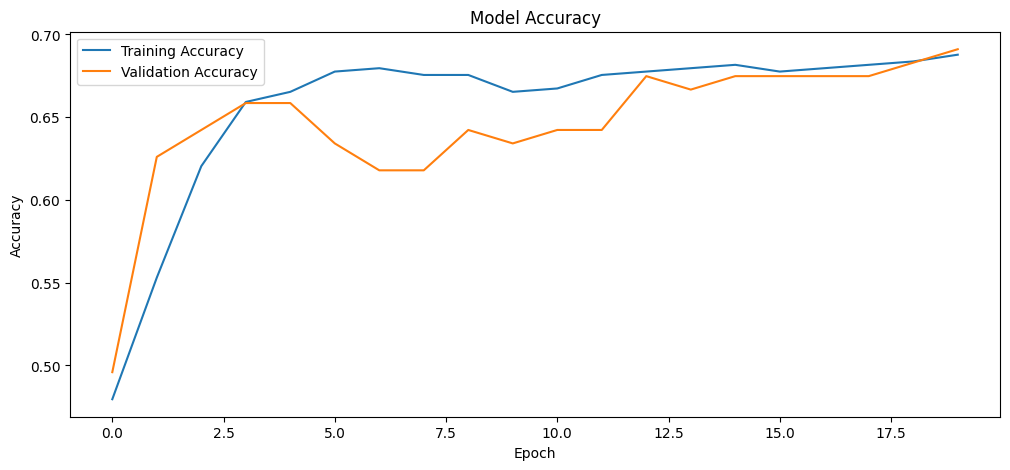

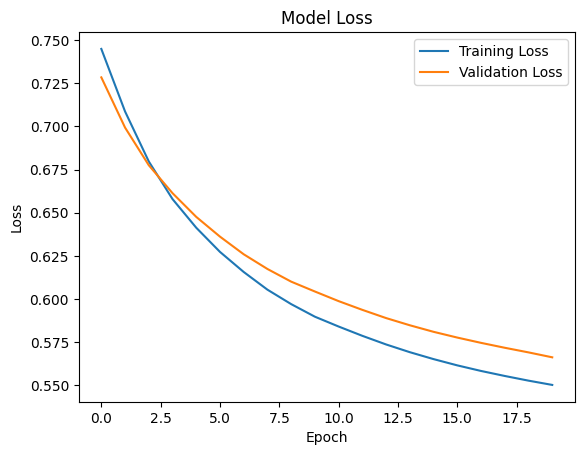

In [17]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Plot Loss Graph

Evaluate model

In [18]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", loss)
print("Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6818 - loss: 0.5686 

Test Loss: 0.5686290860176086
Test Accuracy: 0.6818181872367859


 Predict Class Labels

In [19]:

y_pred = model.predict(X_test)

y_pred = (y_pred > 0.5).astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


confusion_matrix

In [20]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)



Confusion Matrix
[[88  9]
 [40 17]]


Classification Report

In [21]:
print("\nClassification Report")
print(classification_report(y_test, y_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.69      0.91      0.78        97
           1       0.65      0.30      0.41        57

    accuracy                           0.68       154
   macro avg       0.67      0.60      0.60       154
weighted avg       0.68      0.68      0.64       154



Accuracy Score

In [22]:
acc = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:", acc)



Accuracy Score: 0.6818181818181818
